In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [97]:
tab = pd.read_csv("results_full_compare.csv")
tab = tab[60:]
tab.reset_index(inplace=True)

In [98]:
# maps to the same block approximations, but different skip configs
mapping_dict = {
    "[]": 0,
    "[3, 4]": 1,
    "[10, 11]": 2,
    "[1]": 3,
    "[11]": 4,
    "[(2, 4)]": 1,
    "[(9, 11)]": 2,
    "[(0, 1)]": 3,
    "[(10, 11)]": 4
}

In [99]:
tab["skip_config"] = tab.apply(lambda row: f"Block: {row['approx_layer']}, MLP: {row['mlp_linearize']}, Attn: {row['attn_linearize']}", axis=1)

In [100]:
tab["mlp_linearize"] = tab["mlp_linearize"].apply(lambda x: mapping_dict[str(x)])
tab["attn_linearize"] = tab["attn_linearize"].apply(lambda x: mapping_dict[str(x)])
tab["approx_layer"] = tab.apply(lambda row: mapping_dict[str(row["approx_layer"])], axis=1)

In [101]:
tab["skip_config"] = tab.apply(lambda row: f"Block: {row['approx_layer']}, MLP: {row['mlp_linearize']}, Attn: {row['attn_linearize']}", axis=1)

In [102]:
tab["skip_label"] = tab.apply(lambda row: row["mlp_linearize"] + row["attn_linearize"] + row["approx_layer"], axis=1)

In [103]:
accuracies = tab[["skip_config", "skip_label", "seed", "accuracy"]].groupby(["skip_config"]).agg({"accuracy": ["mean", "std"], "skip_label": ["first"]}).reset_index().sort_values(by=("accuracy", "mean"), ascending=False)
accuracies.columns = ["skip_config", "accuracy_mean", "accuracy_std", "skip_label"]

In [104]:
accuracies.sort_values(by="skip_label", inplace=True)

In [105]:
accuracies.to_csv("accuracies_by_skip_config.csv", index=False)

Text(0, 0.5, 'Mean Accuracy')

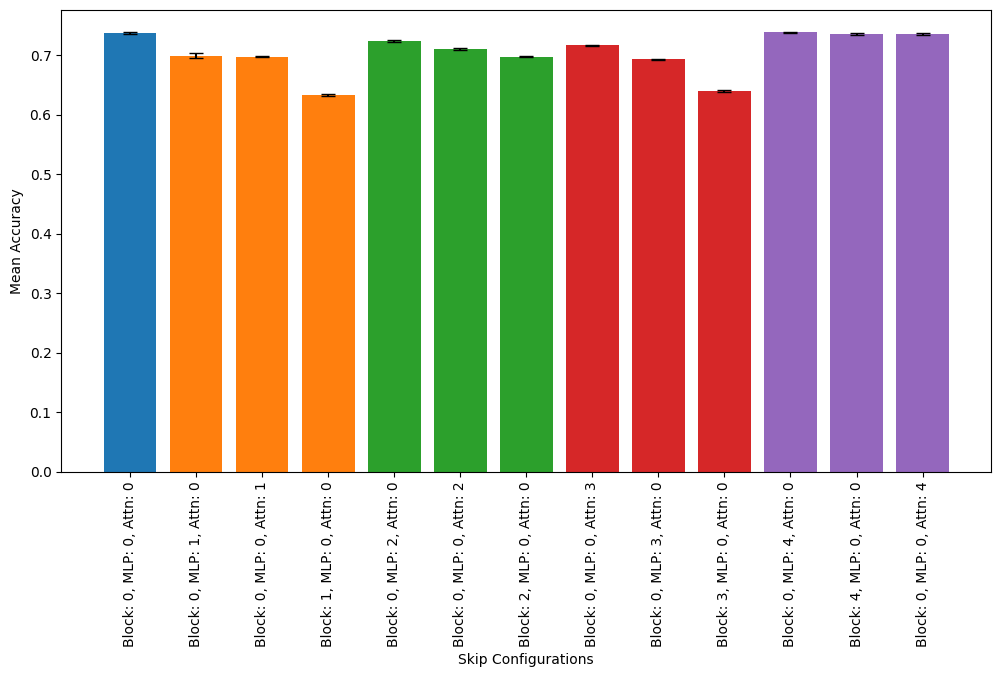

In [106]:
# plot grouped by skip label, with a grouped bar for each skip config
plt.figure(figsize=(12, 6))
for skip_label, group in accuracies.groupby("skip_label"):
    plt.bar(group["skip_config"], group["accuracy_mean"], yerr=group["accuracy_std"], label=f"Skip Label: {skip_label}", capsize=5)
plt.xticks(rotation=90)
plt.xlabel("Skip Configurations")
plt.ylabel("Mean Accuracy")